In [1]:
import sys
import introns
import importlib
import warnings
import pickle

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from Bio import SeqIO
from Bio.SeqUtils import GC
from termcolor import colored
from sklearn.utils import class_weight
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, precision_recall_fscore_support, multilabel_confusion_matrix, confusion_matrix

importlib.reload(introns)

<module 'introns' from '/home/semik/projekty/ml_attempts/noncanonical_introns_ml_solutions_2/introns.py'>

In [2]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
seqs = [i for i in SeqIO.parse("introns_for_3-class_classifier_training.fasta", 'fasta')
        if i.description.split()[-1] != "intron_K"]
train_test_set, true_classes = [], []
for seq in seqs:
    characteristics = introns.compute_intron_characteristics(seq)
    true_class = 1 if seq.description.split()[-1] == 'intron_NK' else 0
    train_test_set.append(characteristics)
    true_classes.append(true_class)

      0  1  2  3  4  5  6  7
0     1  1  0  0  0  0  0  1
1     0  1  0  0  0  0  1  1
2     0  1  0  0  1  0  0  1
3     1  0  0  0  0  0  0  1
4     1  0  0  0  0  0  0  0
...  .. .. .. .. .. .. .. ..
2110  1  0  0  0  0  0  0  0
2111  1  0  1  0  0  0  1  1
2112  1  0  0  0  0  0  1  0
2113  1  0  0  0  0  0  1  0
2114  0  0  1  0  0  0  1  0

[2115 rows x 8 columns]
          0         1         2         3         4   5         6         7
0  1.000000 -0.018262 -0.040664 -0.033405  0.016481 NaN  0.002994 -0.022986
1 -0.018262  1.000000 -0.074780 -0.050643  0.037386 NaN  0.003537 -0.013476
2 -0.040664 -0.074780  1.000000  0.009709 -0.010695 NaN  0.031049  0.010895
3 -0.033405 -0.050643  0.009709  1.000000 -0.003984 NaN -0.009610 -0.014441
4  0.016481  0.037386 -0.010695 -0.003984  1.000000 NaN  0.032037  0.014251
5       NaN       NaN       NaN       NaN       NaN NaN       NaN       NaN
6  0.002994  0.003537  0.031049 -0.009610  0.032037 NaN  1.000000  0.002633
7 -0.022986 -0.0134

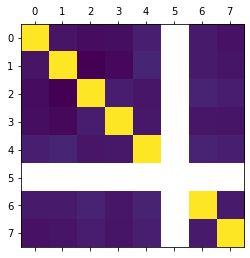

In [4]:
df = pd.DataFrame(train_test_set)
df_c = df.corr()
plt.matshow(df_c)
plt.show()

In [5]:
names = [
    "Ridge Classifier",
    "Linear Prediction",
    "Logistic Regression",
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    RidgeClassifier(),
    SGDClassifier(loss='log'),
    LogisticRegression(random_state=0),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, probability=True),
    SVC(gamma=2, C=1, probability=True),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(train_test_set, true_classes, random_state=2137, shuffle=True)

In [7]:
from xgboost import XGBClassifier


parameters={'booster':['gbtree', 'gblinear', 'dart'],
            'sampling_method':['uniform', 'gradient_based'],
            'importance_type':['gain', 'weight', 'cover', 'total_gain', 'total_cover'],
            'enable_categorical':[True, False],
            'tree_method':['updater','tree_method', 'exact', 'approx', 'hist', 'grow_local_histmaker', 'refresh', 'prune', 'updater', 'tree_method']}



#clf = XGBClassifier()
clf = xgb.XGBClassifier(eval_metric='aucpr')
clf = GridSearchCV(clf, parameters)
clf.fit(X_train, y_train)
y_predicted = clf.predict(X_test)
print(classification_report(y_test, y_predicted))
print(confusion_matrix(y_test, y_predicted), "\n\n")

[02:08:56] WARNING: ../src/learner.cc:627: 
Parameters: { "sampling_method", "tree_method" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[02:08:57] WARNING: ../src/learner.cc:627: 
Parameters: { "sampling_method", "tree_method" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[02:08:58] WARNING: ../src/learner.cc:627: 
Parameters: { "sampling_method", "tree_method" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down

/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
1900 fits failed out of a total of 3000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1200 fits failed with the following error:
Traceback (most recent call last):
  File "/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 681, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/semik/miniconda3/lib/python3.8/site-packages/xgboost/core.py", line 532, in inner_f
    return f(**kwargs)
  File "/home/semik/miniconda3/lib/python3.8/site-packages/xgboost/sklearn.py", line 1379, in fit
    model, metric, params, early_stopping_rounds, callbacks = self._c

[02:20:10] WARNING: ../src/learner.cc:627: 
Parameters: { "sampling_method", "tree_method" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


              precision    recall  f1-score   support

           0       0.79      1.00      0.88       414
           1       0.67      0.03      0.07       115

    accuracy                           0.79       529
   macro avg       0.73      0.51      0.47       529
weighted avg       0.76      0.79      0.70       529

[[412   2]
 [111   4]] 




In [8]:
for name, clf in list(zip(names, classifiers)):
    clf.fit(X_train, y_train)
    y_predicted = clf.predict(X_test)
    print(name, "\n", classification_report(y_test, y_predicted))
    print(confusion_matrix(y_test, y_predicted), "\n\n")

Ridge Classifier 
               precision    recall  f1-score   support

           0       0.78      1.00      0.88       414
           1       0.00      0.00      0.00       115

    accuracy                           0.78       529
   macro avg       0.39      0.50      0.44       529
weighted avg       0.61      0.78      0.69       529

[[414   0]
 [115   0]] 


Linear Prediction 
               precision    recall  f1-score   support

           0       0.79      0.97      0.87       414
           1       0.43      0.08      0.13       115

    accuracy                           0.78       529
   macro avg       0.61      0.52      0.50       529
weighted avg       0.71      0.78      0.71       529

[[402  12]
 [106   9]] 


Logistic Regression 
               precision    recall  f1-score   support

           0       0.79      1.00      0.88       414
           1       0.67      0.03      0.07       115

    accuracy                           0.79       529
   macro avg   

/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Nearest Neighbors 
               precision    recall  f1-score   support

           0       0.81      0.92      0.86       414
           1       0.40      0.20      0.27       115

    accuracy                           0.76       529
   macro avg       0.60      0.56      0.56       529
weighted avg       0.72      0.76      0.73       529

[[380  34]
 [ 92  23]] 




/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Linear SVM 
               precision    recall  f1-score   support

           0       0.78      1.00      0.88       414
           1       0.00      0.00      0.00       115

    accuracy                           0.78       529
   macro avg       0.39      0.50      0.44       529
weighted avg       0.61      0.78      0.69       529

[[414   0]
 [115   0]] 


RBF SVM 
               precision    recall  f1-score   support

           0       0.79      0.97      0.87       414
           1       0.41      0.08      0.13       115

    accuracy                           0.78       529
   macro avg       0.60      0.52      0.50       529
weighted avg       0.71      0.78      0.71       529

[[401  13]
 [106   9]] 


Gaussian Process 
               precision    recall  f1-score   support

           0       0.79      1.00      0.88       414
           1       0.67      0.03      0.07       115

    accuracy                           0.79       529
   macro avg       0.73      0.51 

/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/semik/miniconda3/lib/pyth

Neural Net 
               precision    recall  f1-score   support

           0       0.78      1.00      0.88       414
           1       0.00      0.00      0.00       115

    accuracy                           0.78       529
   macro avg       0.39      0.50      0.44       529
weighted avg       0.61      0.78      0.69       529

[[414   0]
 [115   0]] 


AdaBoost 
               precision    recall  f1-score   support

           0       0.79      1.00      0.88       414
           1       0.71      0.04      0.08       115

    accuracy                           0.79       529
   macro avg       0.75      0.52      0.48       529
weighted avg       0.77      0.79      0.71       529

[[412   2]
 [110   5]] 


Naive Bayes 
               precision    recall  f1-score   support

           0       0.82      0.92      0.87       414
           1       0.49      0.29      0.36       115

    accuracy                           0.78       529
   macro avg       0.65      0.60     

/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
